<a href="https://colab.research.google.com/github/veronicagomariz/IngenieriaVeroG/blob/master/ENTREGA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1️⃣ Crear documento en Google Colab y cargar los datasets

📌 Paso 1: Subir los archivos

En Colab:

In [ ]:
import pandas as pd

# Cargar archivos (subilos a Colab primero)
ventas = pd.read_csv('/content/ventas.csv')
clientes = pd.read_csv('/content/clientes.csv')
marketing = pd.read_csv('/content/marketing.csv')

# Ver primeras filas
print("Ventas:")
display(ventas.head())

print("Clientes:")
display(clientes.head())

print("Marketing:")
display(marketing.head())

Ventas:


,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,$69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,$105.10,5.0,02/01/2024,Decoración
2,1156,Secadora,$97.96,3.0,02/01/2024,Electrodomésticos
3,1372,Heladera,$114.35,8.0,02/01/2024,Electrodomésticos
4,1546,Secadora,$106.21,4.0,02/01/2024,Electrodomésticos


Clientes:


,id_cliente,nombre,edad,ciudad,ingresos
0,1,Aloysia Screase,44,Mar del Plata,42294.68
1,2,Kristina Scaplehorn,25,Posadas,24735.04
2,3,Filip Castagne,50,Resistencia,35744.85
3,4,Liuka Luard,39,Bahía Blanca,27647.96
4,5,Dore Cockshtt,28,Rosario,28245.65


Marketing:


,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,20/03/2024,03/05/2024
1,12,Tablet,RRSS,3.40,26/03/2024,13/05/2024
2,32,Lámpara de mesa,Email,5.54,28/03/2024,20/04/2024
3,21,Smartphone,RRSS,6.37,29/03/2024,16/05/2024
4,58,Alfombra,Email,4.25,31/03/2024,05/05/2024


📌 2. Script básico: calcular ventas mensuales

(Suponiendo que tenés columnas como precio, cantidad y fecha)

---



In [ ]:

# Limpiar columnas (por si vienen como texto)
ventas['precio'] = ventas['precio'].astype(str).str.replace(',', '').str.replace('$', '').str.strip()
ventas['cantidad'] = ventas['cantidad'].astype(str).str.strip()

# Convertir a numérico
ventas['precio'] = pd.to_numeric(ventas['precio'], errors='coerce')
ventas['cantidad'] = pd.to_numeric(ventas['cantidad'], errors='coerce')

# Eliminar filas con datos inválidos
ventas = ventas.dropna(subset=['precio', 'cantidad'])

ventas.info()


<class 'pandas.core.frame.DataFrame'>
Index: 3033 entries, 0 to 3034
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venta     3033 non-null   int64  
 1   producto     3033 non-null   object 
 2   precio       3033 non-null   float64
 3   cantidad     3033 non-null   float64
 4   fecha_venta  3033 non-null   object 
 5   categoria    3033 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 165.9+ KB


3. Estructuras de datos (listas vs diccionarios)

👉 Acá tenés que justificar qué usar.

✔ Opción recomendada: diccionario

Porque cada producto tiene atributos (precio, cantidad, etc.)

In [ ]:
ventas_dict = [
    {"producto": "Laptop", "precio": 1000, "cantidad": 2},
    {"producto": "Mouse", "precio": 50, "cantidad": 5},
    {"producto": "Teclado", "precio": 80, "cantidad": 3}
]

# Calcular total
for v in ventas_dict:
    total = v["precio"] * v["cantidad"]
    print(f"{v['producto']} → Total: {total}")


Laptop → Total: 2000
Mouse → Total: 250
Teclado → Total: 240


📌 Conclusión:

Lista → guarda múltiples elementos
Diccionario → mejor para datos estructurados (clave-valor)
👉 Por eso usamos lista de diccionarios

In [ ]:
ventas_lista = [
    ["Producto A", 1000, 3],
    ["Producto B", 2000, 2]
]


✅ 4. Análisis exploratorio inicial (EDA)



In [ ]:
# Información general
print(ventas.info())

# Estadísticas
print(ventas.describe())

# Columnas
print(ventas.columns)

# Valores únicos
print(ventas.nunique())

# Ver distribución de productos
print(ventas['producto'].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 3033 entries, 0 to 3034
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venta     3033 non-null   int64  
 1   producto     3033 non-null   object 
 2   precio       3033 non-null   float64
 3   cantidad     3033 non-null   float64
 4   fecha_venta  3033 non-null   object 
 5   categoria    3033 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 165.9+ KB
None
          id_venta       precio     cantidad
count  3033.000000  3033.000000  3033.000000
mean   1499.917903    75.289034     6.496538
std     866.520419    28.734666     3.457250
min       1.000000    26.000000     1.000000
25%     749.000000    50.020000     3.000000
50%    1502.000000    75.270000     7.000000
75%    2250.000000   100.040000     9.000000
max    3000.000000   124.970000    12.000000
Index(['id_venta', 'producto', 'precio', 'cantidad', 'fecha_venta',
       'categoria'],


✅ 5. Calidad de datos (nulos y duplicados)

In [ ]:
# Valores nulos
print("Valores nulos:")
print(ventas.isnull().sum())

# Filas duplicadas
print("Duplicados:")
print(ventas.duplicated().sum())


Valores nulos:
id_venta       0
producto       0
precio         0
cantidad       0
fecha_venta    0
categoria      0
dtype: int64
Duplicados:
35


## Etapa 2: Preprocesamiento y Limpieza de Datos

In [ ]:
# Eliminar duplicados
filas_antes = len(ventas)
ventas = ventas.drop_duplicates()
filas_despues = len(ventas)

# Limpiar caracteres en columnas numéricas
ventas['precio'] = ventas['precio'].astype(str).str.replace(',', '').str.replace('$', '').str.strip()
ventas['cantidad'] = ventas['cantidad'].astype(str).str.strip()

# Convertir a numérico
ventas['precio'] = pd.to_numeric(ventas['precio'], errors='coerce')
ventas['cantidad'] = pd.to_numeric(ventas['cantidad'], errors='coerce')

# Eliminar nulos
ventas = ventas.dropna(subset=['precio', 'cantidad'])

print("Filas antes:", filas_antes)
print("Filas después:", len(ventas))

Filas antes: 3033
Filas después: 2998


✅ 2. TRANSFORMACIÓN DE DATOS

In [ ]:
# Crear columna total de venta
ventas['total_venta'] = ventas['precio'] * ventas['cantidad']

# Definir umbral de alto rendimiento (ej: promedio)
umbral = ventas['total_venta'].mean()

# Filtrar productos de alto rendimiento
alto_rendimiento = ventas[ventas['total_venta'] > umbral]

print("Productos de alto rendimiento:")
display(alto_rendimiento.head())

Productos de alto rendimiento:


,id_venta,producto,precio,cantidad,fecha_venta,categoria,total_venta
1,811,Lámpara de mesa,105.10,5.0,02/01/2024,Decoración,525.50
3,1372,Heladera,114.35,8.0,02/01/2024,Electrodomésticos,914.80
7,2959,Proyector,88.17,9.0,02/01/2024,Electrónica,793.53
8,318,Rincón de plantas,79.86,11.0,03/01/2024,Decoración,878.46
9,419,Candelabro,66.11,8.0,03/01/2024,Decoración,528.88


✅ 3. AGREGACIÓN

💻 Código

(Suponiendo que existe columna categoria)

In [ ]:
ventas_categoria = ventas.groupby('categoria')['total_venta'].sum().sort_values(ascending=False)

print("Ventas por categoría:")
print(ventas_categoria)

Ventas por categoría:
categoria
Electrodomésticos    505299.63
Electrónica          482577.80
Decoración           479216.09
Name: total_venta, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. CARGAR DATOS
# =========================
ventas = pd.read_csv('/content/ventas.csv')

# =========================
# 2. LIMPIAR NOMBRES
# =========================
ventas.columns = ventas.columns.str.strip().str.lower()

# =========================
# 3. LIMPIEZA DE DATOS
# =========================
ventas['precio'] = ventas['precio'].astype(str).str.replace(',', '').str.replace('$', '').str.strip()
ventas['cantidad'] = ventas['cantidad'].astype(str).str.strip()

ventas['precio'] = pd.to_numeric(ventas['precio'], errors='coerce')
ventas['cantidad'] = pd.to_numeric(ventas['cantidad'], errors='coerce')

ventas = ventas.dropna(subset=['precio', 'cantidad'])

# =========================
# 4. USAR LA COLUMNA CORRECTA 🔥
# =========================
ventas['fecha_venta'] = pd.to_datetime(ventas['fecha_venta'], errors='coerce')
ventas = ventas.dropna(subset=['fecha_venta'])

# Crear mes
ventas['mes'] = ventas['fecha_venta'].dt.to_period('M')

# =========================
# 5. CALCULAR VENTAS
# =========================
ventas['total_venta'] = ventas['precio'] * ventas['cantidad']

# =========================
# 6. AGRUPAR
# =========================
ventas_mensuales = ventas.groupby('mes')['total_venta'].sum().sort_index()

# =========================
# 7. MOSTRAR
# =========================
print("Ventas mensuales:")
display(ventas_mensuales)


Ventas mensuales:


,total_venta
mes,
2024-01,35813.42
2024-02,62419.50
2024-03,41350.64
2024-04,40841.22
2024-05,49496.33
2024-06,50875.32
2024-07,58644.45
2024-08,52239.92
2024-09,42206.39


✅ 4. INTEGRACIÓN DE DATOS
💻 Código

(Suponiendo una columna en común, por ejemplo producto o campaña_id)

In [ ]:
df_integrado = ventas.merge(marketing, on='producto', how='left')

print("Dataset integrado:")
display(df_integrado.head())

Dataset integrado:


,id_venta,producto,precio,cantidad,fecha_venta,categoria,mes,total_venta,id_campanha,canal,costo,fecha_inicio,fecha_fin
0,792,Cuadro decorativo,69.94,5.0,2024-02-01,Decoración,2024-02,349.7,1,RRSS,5.27,27/04/2024,04/06/2024
1,792,Cuadro decorativo,69.94,5.0,2024-02-01,Decoración,2024-02,349.7,31,Email,5.28,15/08/2024,12/09/2024
2,792,Cuadro decorativo,69.94,5.0,2024-02-01,Decoración,2024-02,349.7,61,TV,5.30,05/11/2024,23/12/2024
3,811,Lámpara de mesa,105.10,5.0,2024-02-01,Decoración,2024-02,525.5,32,Email,5.54,28/03/2024,20/04/2024
4,811,Lámpara de mesa,105.10,5.0,2024-02-01,Decoración,2024-02,525.5,2,RRSS,5.88,30/05/2024,29/06/2024


📊 ETAPA 3 – Análisis de Datos 🎯 Objetivo

Realizar análisis estadísticos y exploratorios sobre los datos procesados para identificar patrones, tendencias y comportamientos en las ventas.

1️⃣ Estadística Descriptiva 📌 Medidas de tendencia central

Primero calculamos el total de ventas:

In [ ]:
ventas["total_venta"] = ventas["precio"] * ventas["cantidad"]
total_ventas = ventas["total_venta"].sum()
print("Total de ventas:", total_ventas)

Total de ventas: 582977.22


In [ ]:
#Media (promedio)
media_ventas = ventas["total_venta"].mean()
print("Media de ventas:", media_ventas)
#Indica el promedio de ventas.

#Mediana
mediana_ventas = ventas["total_venta"].median()
print("Mediana de ventas:", mediana_ventas)
#Indica el valor central de las ventas.

#Moda
moda_ventas = ventas["total_venta"].mode()
print("Moda de ventas:", moda_ventas)
#Indica el valor que más se repite.

Media de ventas: 490.3088477712363
Mediana de ventas: 418.33000000000004
Moda de ventas: 0    345.72
Name: total_venta, dtype: float64


2- Medidas de dispersión

In [ ]:
from numpy._core.fromnumeric import var
#Desviación estándar
desviacion = ventas["total_venta"].std()
print("Desviación estándar de ventas:", desviacion)
#Indica la dispersión de los datos.

#Varianza
varianza = ventas["total_venta"].var()
print("Varianza de ventas:", varianza)
#Indica la variabilidad de los datos.

#Rango
rango = ventas["total_venta"].max() - ventas["total_venta"].min()
print("Rango de ventas:", rango)
#Diferencia entre la venta máxima y mínima

ventas["total_venta"].describe()

Desviación estándar de ventas: 336.5988337670945
Varianza de ventas: 113298.77489336811
Rango de ventas: 1460.2900000000002


3️⃣ Análisis Exploratorio de Datos (EDA) 📌 Importar librerías

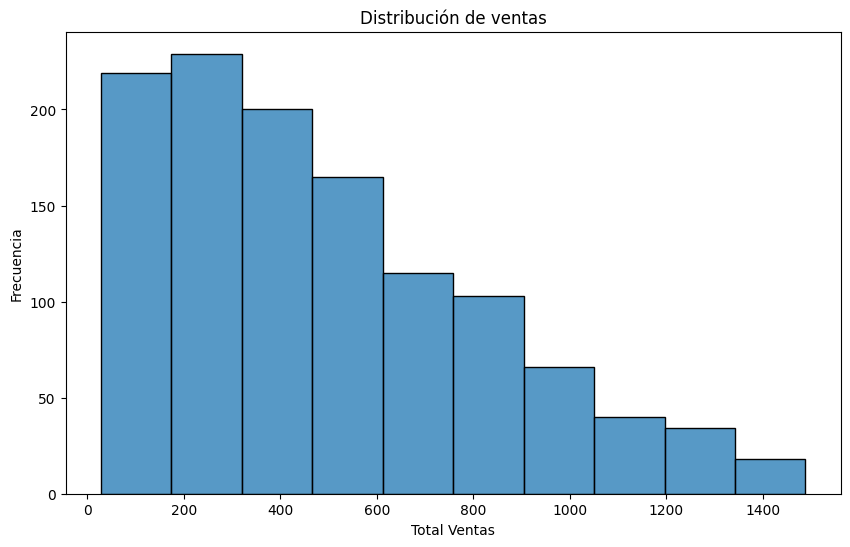

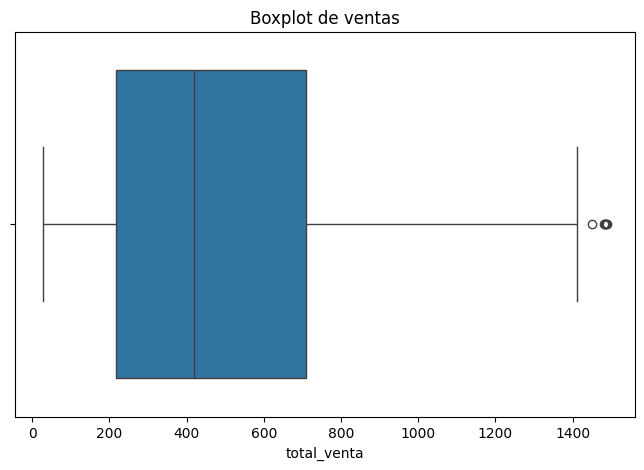

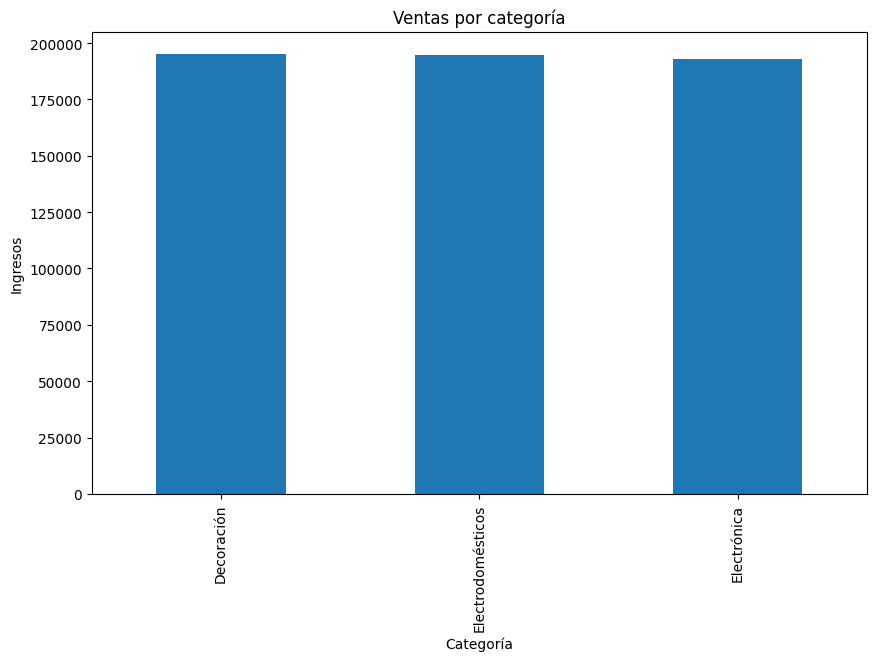

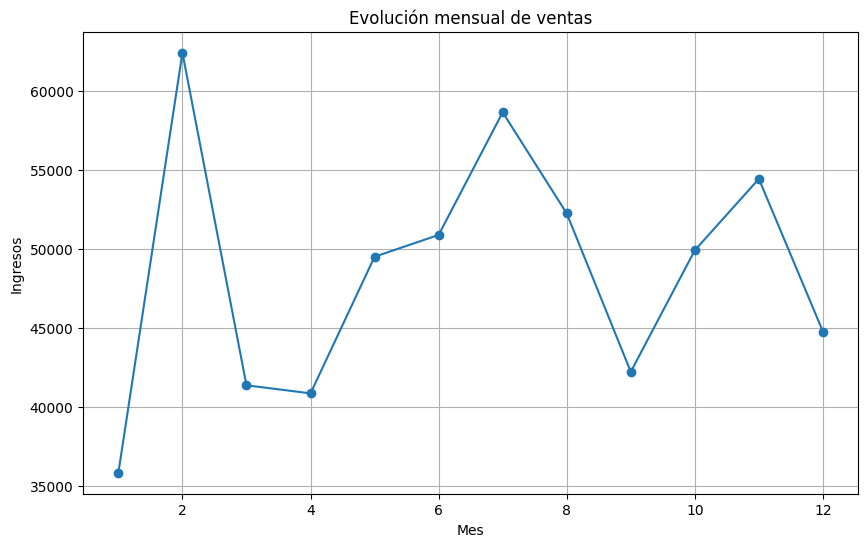

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Histograma de ventas
plt.figure(figsize=(10, 6))
sns.histplot(ventas["total_venta"], bins=10)
plt.title("Distribución de ventas")
plt.xlabel("Total Ventas")
plt.ylabel("Frecuencia")
plt.show()

#Permite observar: concentración de ventas / distribución / posibles valores extremos

#Boxplot de ventas
plt.figure(figsize=(8, 5))
sns.boxplot(x=ventas["total_venta"])
plt.title("Boxplot de ventas")
plt.show()
#Sirve para detectar: outliers / dispersión / cuartiles

#Ventas por categoría
ventas_categoria = ventas.groupby("categoria")["total_venta"].sum()
ventas_categoria.plot(kind="bar", figsize=(10, 6))
plt.title("Ventas por categoría")
plt.xlabel("Categoría")
plt.ylabel("Ingresos")
plt.show()
#Permitir comparar ingresos entre categorías

#Evolución mensual de ventas
ventas["mes"] = ventas["fecha_venta"].dt.month
ventas_mes = ventas.groupby("mes")["total_venta"].sum()
ventas_mes.plot(kind="line", marker="o", figsize=(10, 6))
plt.title("Evolución mensual de ventas")
plt.xlabel("Mes")
plt.ylabel("Ingresos")
plt.grid()
plt.show()
#Ayuda a identificar: tendencias/crecimiento/meses de mayor venta
